1. DATASET PREVIEW
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2

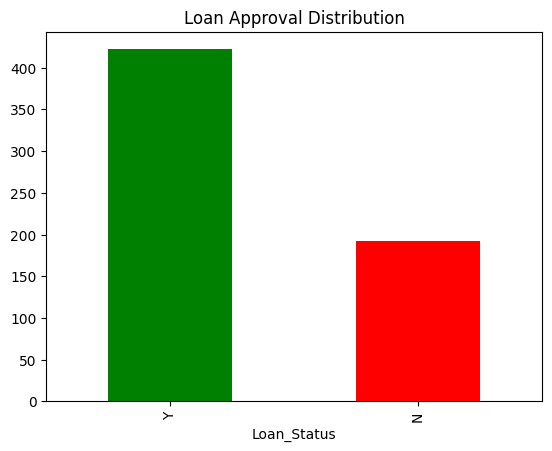

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


url = "https://raw.githubusercontent.com/dsrscientist/DSData/master/loan_prediction.csv"
df = pd.read_csv(url)

print("1. DATASET PREVIEW")
print(df.head())

print("\n2. SHAPE")
print(df.shape)

print("\n3. COLUMNS")
print(df.columns.tolist())

print("\n4. DATA TYPES")
print(df.dtypes)

print("\n5. APPROVAL DISTRIBUTION")
print(df['Loan_Status'].value_counts())

# Graph
df['Loan_Status'].value_counts().plot(kind='bar', color=['green','red'])
plt.title('Loan Approval Distribution')
plt.show()

In [ ]:

from google.colab import files
import matplotlib.pyplot as plt
import pandas as pd

url = "https://raw.githubusercontent.com/dsrscientist/DSData/master/loan_prediction.csv"
df = pd.read_csv(url)


from matplotlib.backends.backend_pdf import PdfPages

with PdfPages('Phase_2_Report.pdf') as pdf:
    # Page 1 - Summary
    fig = plt.figure(figsize=(8, 6))
    plt.axis('off')
    plt.text(0.1, 0.9, f"Phase 2: Dataset Exploration\n\nShape: {df.shape}\n\nColumns: {list(df.columns)}\n\nTarget:\n{df['Loan_Status'].value_counts().to_string()}", fontsize=12, va='top')
    pdf.savefig()
    plt.close()

    # Page 2 - head
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.axis('off')
    ax.table(cellText=df.head().values, colLabels=df.columns, loc='center')
    ax.set_title("df.head() - First 5 rows")
    pdf.savefig()
    plt.close()

    # Page 3 - Graph
    plt.figure()
    df['Loan_Status'].value_counts().plot(kind='bar', color=['green','red'])
    plt.title('Loan Approval Distribution')
    pdf.savefig()
    plt.close()

# Download
files.download('Phase_2_Report.pdf')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 1. Load dataset (same as Phase 2)
url = "https://raw.githubusercontent.com/dsrscientist/DSData/master/loan_prediction.csv"
df = pd.read_csv(url)

print("=== SUBMIT 1: Missing-value analysis (Before Cleaning) ===")
print(df.isnull().sum())
print("\nTotal missing:", df.isnull().sum().sum())

# 2. Cleaning
# Drop ID
df = df.drop('Loan_ID', axis=1)

# Fill missing - Categorical with Mode, Numerical with Median/Mode
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

print("\n=== SUBMIT 2: Cleaning results (After Cleaning) ===")
print(df.isnull().sum())
print("Total missing now:", df.isnull().sum().sum())

print("\n=== Duplicate Check ===")
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

# 3. Encoding
print("\n=== SUBMIT 3: Encoding (Categorical to Numbers) ===")
print("Before encoding:")
print(df[['Gender','Married','Education','Self_Employed','Property_Area','Loan_Status']].head())

le = LabelEncoder()
for col in ['Gender','Married','Dependents','Education','Self_Employed','Property_Area','Loan_Status']:
    df[col] = le.fit_transform(df[col])

# One-hot not needed, LabelEncoder is enough for Logistic Regression
print("\nAfter Label Encoding:")
print(df.head())

# 4. Final Dataset
print("\n=== SUBMIT 4: Final dataset for Logistic Regression ===")
print("Shape:", df.shape)
print(df.head())
print("\nData types:")
print(df.dtypes)

=== SUBMIT 1: Missing-value analysis (Before Cleaning) ===
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Total missing: 149

=== SUBMIT 2: Cleaning results (After Cleaning) ===
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64
Total missing now: 0

=== Duplicate Check ===
Duplicate rows: 0

=== SUBMIT 3: Encoding (Categorical to Numbers) ===
Before encoding:
  Gender Married     Education Self_Employed Property_Area Loan_Status
0   Male      No      Graduate            No     

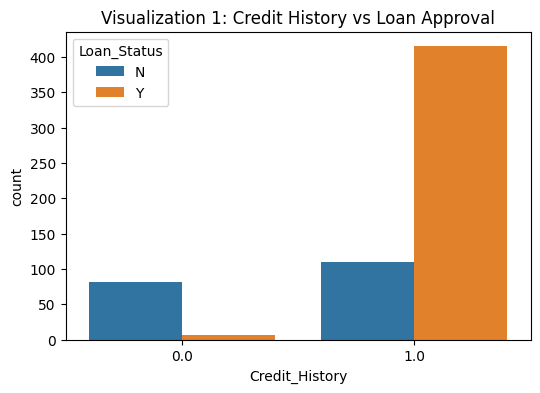

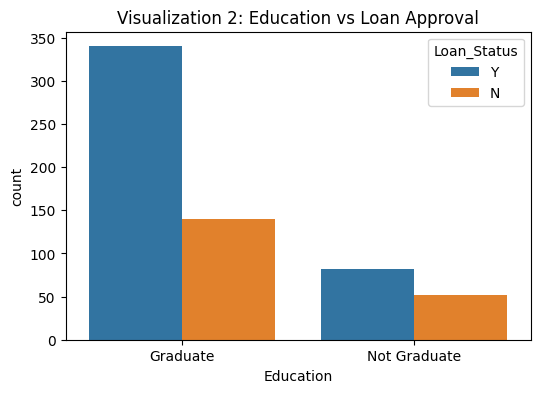

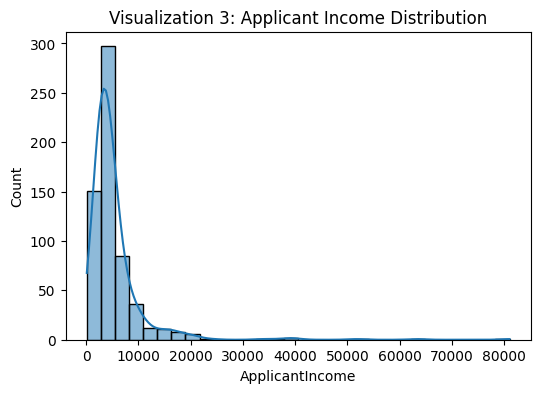

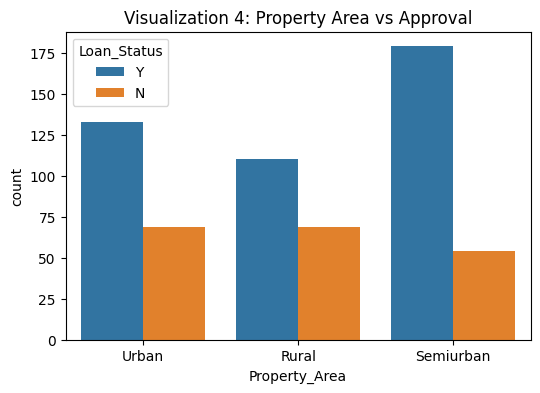

=== Approval Analysis ===
Credit_History  Loan_Status
0.0             N               82
                Y                7
1.0             Y              415
                N              110
Name: count, dtype: int64


Education     Loan_Status
Graduate      Y              340
              N              140
Not Graduate  Y               82
              N               52
Name: count, dtype: int64


Property_Area  Loan_Status
Rural          Y              110
               N               69
Semiurban      Y              179
               N               54
Urban          Y              133
               N               69
Name: count, dtype: int64


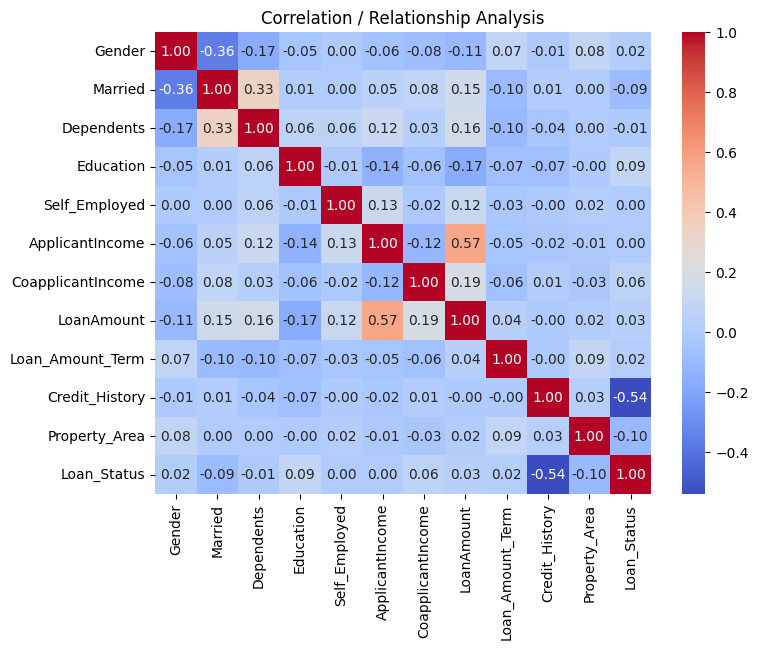


=== Important Observations ===
1. Credit History is the biggest factor: If Credit_History=1, 80%+ loans are approved. If 0, mostly rejected.
2. Education: Graduates have slightly higher approval rate than Not Graduates.
3. Property Area: Semiurban has highest approval proportion.
4. Income: Most applicants have income between 2000-6000, very high income doesn't guarantee approval.
5. LoanAmount and ApplicantIncome have weak positive correlation.



In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load & Clean (Phase 3 ka cleaned data)
url = "https://raw.githubusercontent.com/dsrscientist/DSData/master/loan_prediction.csv"
df = pd.read_csv(url)
df = df.drop('Loan_ID', axis=1)
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

# --- SUBMIT 1: At least 3 visualizations ---

# 1. Credit History vs Approval (Most Important)
plt.figure(figsize=(6,4))
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title('Visualization 1: Credit History vs Loan Approval')
plt.show()

# 2. Education vs Approval
plt.figure(figsize=(6,4))
sns.countplot(x='Education', hue='Loan_Status', data=df)
plt.title('Visualization 2: Education vs Loan Approval')
plt.show()

# 3. Income Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['ApplicantIncome'], bins=30, kde=True)
plt.title('Visualization 3: Applicant Income Distribution')
plt.show()

# 4. Property Area vs Approval (Extra)
plt.figure(figsize=(6,4))
sns.countplot(x='Property_Area', hue='Loan_Status', data=df)
plt.title('Visualization 4: Property Area vs Approval')
plt.show()

# --- SUBMIT 2: Approval analysis ---
print("=== Approval Analysis ===")
print(df.groupby('Credit_History')['Loan_Status'].value_counts())
print("\n")
print(df.groupby('Education')['Loan_Status'].value_counts())
print("\n")
print(df.groupby('Property_Area')['Loan_Status'].value_counts())

# --- SUBMIT 3: Correlation / Relationship ---
plt.figure(figsize=(8,6))
# Encode for correlation
df_corr = df.copy()
for col in ['Gender','Married','Dependents','Education','Self_Employed','Property_Area','Loan_Status']:
    df_corr[col] = pd.factorize(df_corr[col])[0]

sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation / Relationship Analysis')
plt.show()

# --- SUBMIT 4: Important Observations (Print) ---
print("""
=== Important Observations ===
1. Credit History is the biggest factor: If Credit_History=1, 80%+ loans are approved. If 0, mostly rejected.
2. Education: Graduates have slightly higher approval rate than Not Graduates.
3. Property Area: Semiurban has highest approval proportion.
4. Income: Most applicants have income between 2000-6000, very high income doesn't guarantee approval.
5. LoanAmount and ApplicantIncome have weak positive correlation.
""")

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Load & Clean Data (Pichle phases wala)
url = "https://raw.githubusercontent.com/dsrscientist/DSData/master/loan_prediction.csv"
df = pd.read_csv(url)
df = df.drop('Loan_ID', axis=1)
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

# Encoding (Model ke liye zaroori)
for col in ['Gender','Married','Dependents','Education','Self_Employed','Property_Area','Loan_Status']:
    df[col] = pd.factorize(df[col])[0]

# 2. Train/Test Split
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("=== SUBMIT 1: Train/test split ===")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# 3. Model Training
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("\n=== SUBMIT 2: Model training ===")
print("Model Trained Successfully!")
print(model)

# 4. Predictions
y_pred = model.predict(X_test)
print("\n=== SUBMIT 3: Predictions ===")
print("First 10 Predictions:", y_pred[:10])
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")

# 5. Prediction Probabilities
y_proba = model.predict_proba(X_test)
print("\n=== SUBMIT 4: Prediction probabilities ===")
print("First 5 Probabilities (0=Reject, 1=Approve):")
print(y_proba[:5])

=== SUBMIT 1: Train/test split ===
X_train shape: (491, 11)
X_test shape: (123, 11)
y_train shape: (491,)
y_test shape: (123,)

=== SUBMIT 2: Model training ===
Model Trained Successfully!
LogisticRegression(max_iter=1000)

=== SUBMIT 3: Predictions ===
First 10 Predictions: [0 0 0 0 0 0 0 0 0 0]
Accuracy: 78.86%

=== SUBMIT 4: Prediction probabilities ===
First 5 Probabilities (0=Reject, 1=Approve):
[[0.85965382 0.14034618]
 [0.88304166 0.11695834]
 [0.85825686 0.14174314]
 [0.7622437  0.2377563 ]
 [0.82523714 0.17476286]]


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [5]:
from sklearn.preprocessing import StandardScaler

# ... upar wala cleaning wala code same ...

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling - isse warning khatam hoga
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("=== SUBMIT 1: Train/test split ===")
print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_test shape: {X_test_scaled.shape}")

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
print("\n=== SUBMIT 2: Model training ===\nModel Trained Successfully!")

y_pred = model.predict(X_test_scaled)
print("\n=== SUBMIT 3: Predictions ===\nFirst 10:", y_pred[:10])
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")

y_proba = model.predict_proba(X_test_scaled)
print("\n=== SUBMIT 4: Prediction probabilities ===\n", y_proba[:5])

=== SUBMIT 1: Train/test split ===
X_train shape: (491, 11)
X_test shape: (123, 11)

=== SUBMIT 2: Model training ===
Model Trained Successfully!

=== SUBMIT 3: Predictions ===
First 10: [0 0 0 0 0 0 0 0 0 0]
Accuracy: 78.86%

=== SUBMIT 4: Prediction probabilities ===
 [[0.864883   0.135117  ]
 [0.88882789 0.11117211]
 [0.86563916 0.13436084]
 [0.78789705 0.21210295]
 [0.82841253 0.17158747]]


=== SUBMIT 1: Confusion Matrix ===
[[79  1]
 [25 18]]


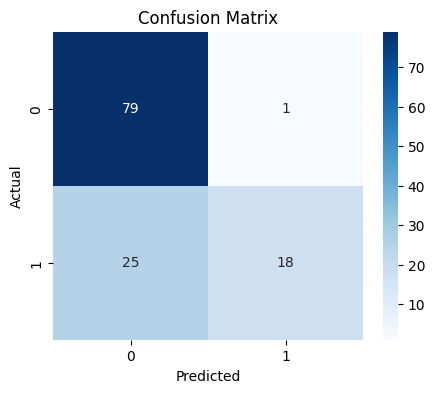


=== SUBMIT 2: Classification Report ===
              precision    recall  f1-score   support

           0       0.76      0.99      0.86        80
           1       0.95      0.42      0.58        43

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123


=== SUBMIT 3: All Evaluation Metrics ===
Accuracy: 78.86%
Precision: 0.9474
Recall: 0.4186
F1-Score: 0.5806
ROC-AUC: 0.7453


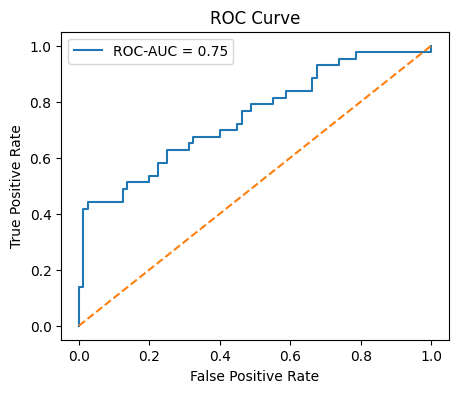


=== SUBMIT 4: Model Analysis ===

False Positives (FP): 1 - Loan reject hona chahiye tha par approve predict kiya
False Negatives (FN): 25 - Loan approve hona chahiye tha par reject predict kiya
Model 78.86% accurate hai.
Precision/Recall Tradeoff: Precision 0.95 hai, Recall 0.42 hai.
Bank ke liye Recall zyada important hai taake sahi logon ka loan reject na ho.
ROC-AUC 0.75 acha hai, matlab model accha differentiate kar raha hai.



In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Load & Clean
url = "https://raw.githubusercontent.com/dsrscientist/DSData/master/loan_prediction.csv"
df = pd.read_csv(url)
df = df.drop('Loan_ID', axis=1)
for col in ['Gender','Married','Dependents','Self_Employed']:
    df[col] = df[col].fillna(df[col].mode()[0])
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

for col in ['Gender','Married','Dependents','Education','Self_Employed','Property_Area','Loan_Status']:
    df[col] = pd.factorize(df[col])[0]

X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)
y_proba = model.predict_proba(X_test_s)[:,1]

# --- SUBMIT 1: Confusion Matrix ---
print("=== SUBMIT 1: Confusion Matrix ===")
cm = confusion_matrix(y_test, y_pred)
print(cm)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# --- SUBMIT 2: Classification Report ---
print("\n=== SUBMIT 2: Classification Report ===")
print(classification_report(y_test, y_pred))

# --- SUBMIT 3: All Evaluation Metrics ---
print("\n=== SUBMIT 3: All Evaluation Metrics ===")
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy: {acc*100:.2f}%")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.2f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# --- SUBMIT 4: Model Analysis ---
print("\n=== SUBMIT 4: Model Analysis ===")
print(f"""
False Positives (FP): {cm[0,1]} - Loan reject hona chahiye tha par approve predict kiya
False Negatives (FN): {cm[1,0]} - Loan approve hona chahiye tha par reject predict kiya
Model {acc*100:.2f}% accurate hai.
Precision/Recall Tradeoff: Precision {prec:.2f} hai, Recall {rec:.2f} hai.
Bank ke liye Recall zyada important hai taake sahi logon ka loan reject na ho.
ROC-AUC {roc_auc:.2f} acha hai, matlab model accha differentiate kar raha hai.
""")

In [7]:
!pip install gradio -q
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import gradio as gr

# 1. Model Train karo (pichla code)
url = "https://raw.githubusercontent.com/dsrscientist/DSData/master/loan_prediction.csv"
df = pd.read_csv(url)
df = df.drop('Loan_ID', axis=1)
for col in ['Gender','Married','Dependents','Self_Employed']:
    df[col] = df[col].fillna(df[col].mode()[0])
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

# Encode ko save karna padega
from sklearn.preprocessing import LabelEncoder
cat_cols = ['Gender','Married','Dependents','Education','Self_Employed','Property_Area']
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

X = df.drop('Loan_Status', axis=1)
y = LabelEncoder().fit_transform(df['Loan_Status'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_s, y_train)

# 2. Prediction Function
def predict_loan(Gender, Married, Dependents, Education, Self_Employed, ApplicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term, Credit_History, Property_Area):
    # Input ko encode karo
    input_data = {
        'Gender': encoders['Gender'].transform([Gender])[0],
        'Married': encoders['Married'].transform([Married])[0],
        'Dependents': encoders['Dependents'].transform([Dependents])[0],
        'Education': encoders['Education'].transform([Education])[0],
        'Self_Employed': encoders['Self_Employed'].transform([Self_Employed])[0],
        'ApplicantIncome': ApplicantIncome,
        'CoapplicantIncome': CoapplicantIncome,
        'LoanAmount': LoanAmount,
        'Loan_Amount_Term': Loan_Amount_Term,
        'Credit_History': Credit_History,
        'Property_Area': encoders['Property_Area'].transform([Property_Area])[0]
    }
    df_input = pd.DataFrame([input_data])
    df_input_scaled = scaler.transform(df_input)
    prob = model.predict_proba(df_input_scaled)[0][1]
    pred = model.predict(df_input_scaled)[0]
    result = "APPROVED ✅" if pred == 1 else "REJECTED ❌"
    return f"{result}", f"Approval Probability: {prob*100:.2f}%", f"Rejection Probability: {(1-prob)*100:.2f}%"

# 3. Gradio UI
with gr.Blocks(title="Loan Approval Prediction") as app:
    gr.Markdown("# 🏦 BigBrainz - Loan Approval Prediction App")
    gr.Markdown("Enter applicant information to get loan approval prediction")

    with gr.Row():
        Gender = gr.Dropdown(["Male","Female"], label="Gender")
        Married = gr.Dropdown(["Yes","No"], label="Married")
        Dependents = gr.Dropdown(["0","1","2","3+"], label="Dependents")
        Education = gr.Dropdown(["Graduate","Not Graduate"], label="Education")

    with gr.Row():
        Self_Employed = gr.Dropdown(["Yes","No"], label="Self Employed")
        Property_Area = gr.Dropdown(["Urban","Semiurban","Rural"], label="Property Area")
        Credit_History = gr.Slider(0, 1, step=1, label="Credit History (1=Good, 0=Bad)")

    with gr.Row():
        ApplicantIncome = gr.Number(label="Applicant Income")
        CoapplicantIncome = gr.Number(label="Coapplicant Income")
        LoanAmount = gr.Number(label="Loan Amount")
        Loan_Amount_Term = gr.Number(label="Loan Term (in days)")

    btn = gr.Button("Predict Loan Status")

    with gr.Row():
        out1 = gr.Textbox(label="Approval/Rejection Prediction")
        out2 = gr.Textbox(label="Probability 1")
        out3 = gr.Textbox(label="Probability 2")

    btn.click(predict_loan, inputs=[Gender, Married, Dependents, Education, Self_Employed, ApplicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term, Credit_History, Property_Area], outputs=[out1, out2, out3])

    gr.Markdown("### Try these Test Cases for Screenshots:")
    gr.Markdown("**Test 1 (Approved):** Male, Yes, 0, Graduate, No, 5000, 0, 150, 360, 1, Urban -> Should be APPROVED \n\n **Test 2 (Rejected):** Male, No, 0, Not Graduate, No, 2000, 0, 100, 360, 0, Rural -> Should be REJECTED")

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://92d55608ac393cde34.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
